# 1. Environment Setup & Package Configuration

## Purpose
This notebook sets up the production-grade Bayesian Media Mix Model (MMM) for Project **Titan**—a single-rooftop Chrysler/Jeep dealership operating across 104 weeks of historical data (`2024-08-05` to `2026-07-27`).

## Core Stack
* **Data Manipulation**: `numpy`, `pandas`, `scipy.stats`
* **Bayesian Inference Engine**: `pymc` (v5+), `pytensor`
* **MCMC Diagnostics & Visualization**: `arviz`, `matplotlib`, `seaborn`, `plotly`
* **Econometrics & Time Series**: `statsmodels`

Grounding: Following **Jin et al. (2017)** and **Chan & Perry (2017)**, we configure Bayesian samplers for $N=104$ weekly observations with strict reproducibility parameters and robust plotting defaults.

In [14]:
# System & General Utilities
import os
import sys
import json
import warnings
from datetime import datetime

# Core Data Science & Numerical Tools
import numpy as np
import pandas as pd
import scipy.stats as stats
import xarray as xr

# Statistical Testing & Econometrics
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.stattools import adfuller, ccf

# Bayesian Modeling & Diagnostics
import pymc as pm
import arviz as az
import pytensor
import pytensor.tensor as pt

# Static & Interactive Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# Global Notebook Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: '%.4f' % x)
plt.style.use('seaborn-v0_8-whitegrid')

print(f"✅ PyMC Version: {pm.__version__}")
print(f"✅ ArViZ Version: {az.__version__}")

✅ PyMC Version: 6.3.1
✅ ArViZ Version: 1.3.0


# 2. Local Data Ingestion & Sanitization

## Purpose
Streamline data loading by reading directly from the local repository path (`data/raw/Chrysler_Jeep_Workbook_Sheet1.csv`) rather than an external Google Sheet URL.

## Ingestion & Cleaning Pipeline:
1. **Local File Verification**: Locate the dataset in the local directory structure.
2. **Date Parsing**: Convert `week_start` into `datetime64[ns]`.
3. **Currency & Numeric Cleaning**: Strip currency symbols (`$`), commas (`,`), and whitespace across all spend, sales, inventory, and macro variables.
4. **Historical Window Cropping**: Filter strictly to valid historical weeks ($N=104$, up to `2026-07-27`), removing unrecorded future projections or zero-sales anomalies.

In [15]:
# 1. Locate and read local CSV file
local_data_path = os.path.join("..", "data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")
if not os.path.exists(local_data_path):
    local_data_path = os.path.join("data", "raw", "Chrysler_Jeep_Workbook_Sheet1.csv")

df_raw = pd.read_csv(local_data_path)

# 2. Parse dates and clean currency/text formatting
df = df_raw.copy()
df['week_start'] = pd.to_datetime(df['week_start'])

clean_cols = [
    'sales', 'inventory', 'gasregw', 'umcsent', 'search', 'display', 'social', 'pmax', 
    'fp_emails_sent', 'ott_cable', 'broadcast_audio', 'print', 'youtube', 
    'facebook_reels', 'facebook_add', 'direct_mail', 'broadcast_tv'
]

for col in clean_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.replace('$', '', regex=False)
            .str.replace(',', '', regex=False)
            .str.strip()
        )
        df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Filter valid historical window (104 weeks)
df = df[(df['week_start'] <= '2026-07-27') & (df['sales'].notna()) & (df['sales'] > 0)].sort_values('week_start').reset_index(drop=True)

print(f"✅ Data Cleaned & Loaded! Valid Weeks: {len(df)} | Range: {df['week_start'].min().strftime('%Y-%m-%d')} to {df['week_start'].max().strftime('%Y-%m-%d')}")
display(df[['week_start', 'sales', 'inventory', 'eom_intensity', 'gasregw', 'umcsent']].head())

✅ Data Cleaned & Loaded! Valid Weeks: 104 | Range: 2024-08-05 to 2026-07-27


,week_start,sales,inventory,eom_intensity,gasregw,umcsent
0,2024-08-05,13.0000,246.1000,0.0000,3.4500,67.9000
1,2024-08-12,12.0000,238.1000,0.0000,3.4100,67.9000
2,2024-08-19,12.0000,236.7000,0.1429,3.3800,67.9000
3,2024-08-26,17.0000,230.6000,1.0000,3.3100,67.9000
4,2024-09-02,11.0000,222.3000,0.0000,3.2900,70.1000


# 3. Raw Media Sparsity & Co-Spending Profiling

## Purpose
Analyze the sparsity profile (percentage of weeks with zero spend) across all 12 raw media channels.

## Strategic Rationale
High channel sparsity (e.g., >70% zero weeks) on a small dataset ($N=104$) causes parameter non-identifiability and multimodal MCMC sampling. Channels with sparse, intermittent spending must be consolidated into broader strategic media buckets before modeling.

In [16]:
all_drivers = [
    'search', 'display', 'social', 'pmax', 'fp_emails_sent', 'ott_cable',
    'broadcast_audio', 'print', 'youtube', 'facebook_reels', 'facebook_add',
    'direct_mail', 'broadcast_tv'
]
paid_spend_channels = [c for c in all_drivers if c != 'fp_emails_sent']

# Macro Correlation Assessment
macro_corr = df[['gasregw', 'umcsent']].corr().iloc[0, 1]
print(f"=== Macro Correlation Check ===")
print(f"Gas Price vs. Consumer Sentiment Correlation: {macro_corr:.2f}\n")

# Sparsity & Paid Spend Share Table
sparsity_df = pd.DataFrame({
    'Zero_Weeks_Pct': (df[all_drivers] == 0).mean() * 100,
    'Total_Volume_or_Spend': df[all_drivers].sum(),
    'Mean_Weekly': df[all_drivers].mean(),
    'Spend_Share_Pct': (df[paid_spend_channels].sum() / df[paid_spend_channels].sum().sum()) * 100
}).sort_values('Zero_Weeks_Pct', ascending=False)

print("=== Raw Driver Sparsity & Paid Spend Share ===")
display(sparsity_df.round(2))

=== Macro Correlation Check ===
Gas Price vs. Consumer Sentiment Correlation: -0.46

=== Raw Driver Sparsity & Paid Spend Share ===


,Zero_Weeks_Pct,Total_Volume_or_Spend,Mean_Weekly,Spend_Share_Pct
broadcast_audio,93.2700,14999.9900,144.2300,3.4800
facebook_add,93.2700,7000.0200,67.3100,1.6300
display,86.5400,2328.2000,22.3900,0.5400
broadcast_tv,81.7300,49621.1400,477.1300,11.5200
direct_mail,80.7700,127328.0000,1224.3100,29.5700
pmax,75.9600,3115.8100,29.9600,0.7200
print,75.9600,17720.0000,170.3800,4.1200
youtube,67.3100,12249.9800,117.7900,2.8500
facebook_reels,53.8500,19750.0100,189.9000,4.5900
ott_cable,53.8500,63001.3700,605.7800,14.6300


# 4. Strategic Consolidation & Control Index Construction

## Purpose
Consolidate the 12 granular sales drivers into **5 Strategic Media Buckets** and construct standardized control indices for automotive-specific drivers.

## Feature Engineering Rules:
1. **Full-Path Digital (`fp_digital`)**: `search` + `pmax` + `display`
2. **Meta Social (`meta_social`)**: `social` + `facebook_reels` + `facebook_add`
3. **Digital Video & OTT (`digital_video_ott`)**: `youtube` + `ott_cable`
4. **Broadcast Media (`broadcast_media`)**: `broadcast_tv` + `broadcast_audio`
5. **Print & Direct Mail (`print_mail`)**: `direct_mail` + `print`

## Controls:
* **Macro Stress Index**: $Z_{\text{gas\_price}} - Z_{\text{sentiment}}$ (Captures macroeconomic purchasing headwind/footwind).
* **Inventory Index**: $Z_{\text{inventory}}$ (Captures dealer lot availability constraints).

In [17]:
# Base design matrix
df_model = df[['week_start', 'sales', 'inventory', 'eom_intensity', 'fp_emails_sent']].copy()

# 1. Macro Stress Index (Gas Price Z-score - Sentiment Z-score)
gas_z = (df['gasregw'] - df['gasregw'].mean()) / df['gasregw'].std()
sent_z = (df['umcsent'] - df['umcsent'].mean()) / df['umcsent'].std()
df_model['macro_stress_index'] = gas_z - sent_z

# 2. Standardized Inventory Index (Z-score)
df_model['inventory_index'] = (df['inventory'] - df['inventory'].mean()) / df['inventory'].std()

# 3. Consolidate into 5 Strategic Buckets
df_model['fp_digital'] = df['search'] + df['pmax'] + df['display']
df_model['meta_social'] = df['social'] + df['facebook_reels'] + df['facebook_add']
df_model['digital_video_ott'] = df['youtube'] + df['ott_cable']
df_model['broadcast_media'] = df['broadcast_tv'] + df['broadcast_audio']
df_model['print_mail'] = df['direct_mail'] + df['print']

consolidated_paid = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']

print("=== Consolidated 5-Channel Sparsity Profile ===")
sparsity_check = pd.DataFrame({
    'Zero_Weeks_Pct': (df_model[consolidated_paid] == 0).mean() * 100,
    'Total_Spend': df_model[consolidated_paid].sum(),
    'Spend_Share_Pct': (df_model[consolidated_paid].sum() / df_model[consolidated_paid].sum().sum()) * 100
}).sort_values('Spend_Share_Pct', ascending=False)

display(sparsity_check.round(2))

=== Consolidated 5-Channel Sparsity Profile ===


,Zero_Weeks_Pct,Total_Spend,Spend_Share_Pct
print_mail,65.3800,145048.0000,33.6900
fp_digital,0.0000,95817.1200,22.2500
digital_video_ott,48.0800,75251.3500,17.4800
broadcast_media,75.0000,64621.1300,15.0100
meta_social,0.0000,49838.8500,11.5700


# 5. Annual Fourier Seasonality Feature Engineering

## Purpose
Construct annual seasonality terms using a second-order ($k=2$) Fourier series with period $P = 52.1429$ weeks.

## Mathematical Formulation
$$F_{1,t} = \sin\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right), \quad F_{2,t} = \cos\left(\frac{2\pi \cdot 1 \cdot t}{52.1429}\right)$$
$$F_{3,t} = \sin\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right), \quad F_{4,t} = \cos\left(\frac{2\pi \cdot 2 \cdot t}{52.1429}\right)$$

## Rationale
Fourier terms model smooth annual dealership sales seasonality while avoiding the rank-deficiency and severe collinearity introduced by 12 categorical monthly indicator variables.

In [18]:
weeks = np.arange(len(df_model))
period = 52.1429

df_model['sin_order1'] = np.sin(2 * np.pi * 1 * weeks / period)
df_model['cos_order1'] = np.cos(2 * np.pi * 1 * weeks / period)
df_model['sin_order2'] = np.sin(2 * np.pi * 2 * weeks / period)
df_model['cos_order2'] = np.cos(2 * np.pi * 2 * weeks / period)

fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

print(f"=== Final Model Design Matrix Verified ({df_model.shape[0]} rows, {df_model.shape[1]} columns) ===")
display(df_model[['week_start', 'sales', 'eom_intensity', 'macro_stress_index', 'inventory_index'] + consolidated_paid + fourier_cols].head())

=== Final Model Design Matrix Verified (104 rows, 16 columns) ===


,week_start,sales,eom_intensity,macro_stress_index,inventory_index,fp_digital,meta_social,digital_video_ott,broadcast_media,print_mail,sin_order1,cos_order1,sin_order2,cos_order2
0,2024-08-05,13.0000,0.0000,-0.7279,1.0450,947.0100,418.8600,0.0000,1846.1500,0.0000,0.0000,1.0000,0.0000,1.0000
1,2024-08-12,12.0000,0.0000,-0.8214,0.8644,928.0000,402.6800,0.0000,1846.1500,0.0000,0.1202,0.9927,0.2387,0.9711
2,2024-08-19,12.0000,0.1429,-0.8915,0.8328,1079.8700,351.1800,0.0000,2461.5400,750.0000,0.2387,0.9711,0.4635,0.8861
3,2024-08-26,17.0000,1.0000,-1.0551,0.6951,1104.4800,497.1500,0.0000,1846.1500,0.0000,0.3537,0.9354,0.6616,0.7498
4,2024-09-02,11.0000,0.0000,-1.3696,0.5077,937.3000,419.7700,0.0000,0.0000,0.0000,0.4635,0.8861,0.8215,0.5702


# 6. Visualizing End-Of-Month Push vs. Annual Fourier Waves

## Purpose
Verify that monthly `eom_intensity` (sawtooth spikes driving up to 50% of monthly sales in Week 4) operates orthogonally to smooth annual Fourier waves.

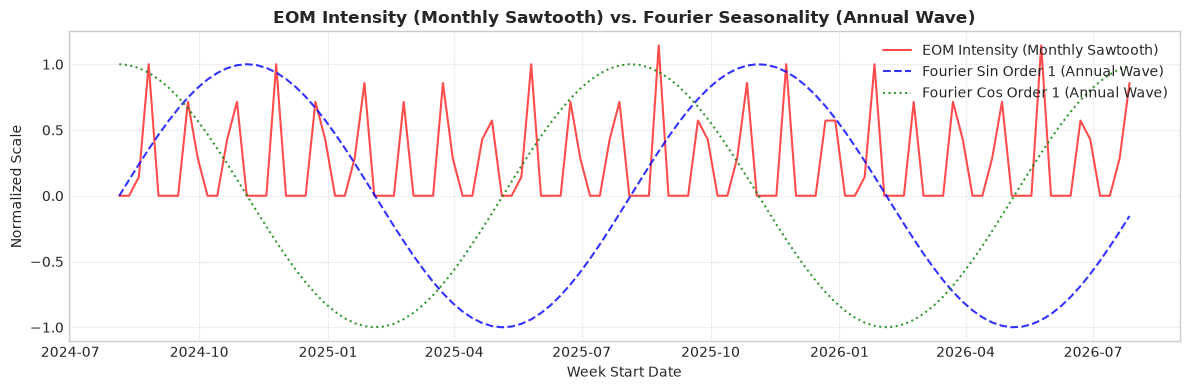

In [19]:
plt.figure(figsize=(12, 4))
plt.plot(df_model['week_start'], df_model['eom_intensity'], label='EOM Intensity (Monthly Sawtooth)', color='red', alpha=0.7, linewidth=1.5)
plt.plot(df_model['week_start'], df_model['sin_order1'], label='Fourier Sin Order 1 (Annual Wave)', color='blue', linestyle='--', alpha=0.8)
plt.plot(df_model['week_start'], df_model['cos_order1'], label='Fourier Cos Order 1 (Annual Wave)', color='green', linestyle=':', alpha=0.8)

plt.title("EOM Intensity (Monthly Sawtooth) vs. Fourier Seasonality (Annual Wave)", fontsize=12, fontweight='bold')
plt.xlabel("Week Start Date")
plt.ylabel("Normalized Scale")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 7. Fast Media Pre-Transformation (Fixed Carryover & Saturation)

## Purpose
Pre-transform media spend using domain-informed Geometric Adstock ($\alpha_m$) and Hill Reach curves ($S_m=1, K_m = \text{Median}(X_{\text{adstocked}, m})$) prior to PyMC model sampling.

## Mathematical Formulation
1. **Geometric Adstock Decay**:
   $$X_{t,m}^{\text{adstock}} = \frac{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l \cdot X_{t-l, m}}{\sum_{l=0}^{L_{\text{max}}-1} \alpha_m^l}$$
2. **Hill Reach Saturation Curve ($S=1$)**:
   $$X^*_{t,m} = \frac{X_{t,m}^{\text{adstock}}}{X_{t,m}^{\text{adstock}} + K_m}$$

## Rationale (Jin et al., 2017)
On $N=104$ weekly observations, estimating non-linear Hill parameters ($K_m, S_m$) inside MCMC creates severe parameter non-identifiability. Pre-computing fixed transformations converts the non-linear sampling problem into a well-conditioned Bayesian Linear Regression, accelerating sampling speed and eliminating divergent transitions.

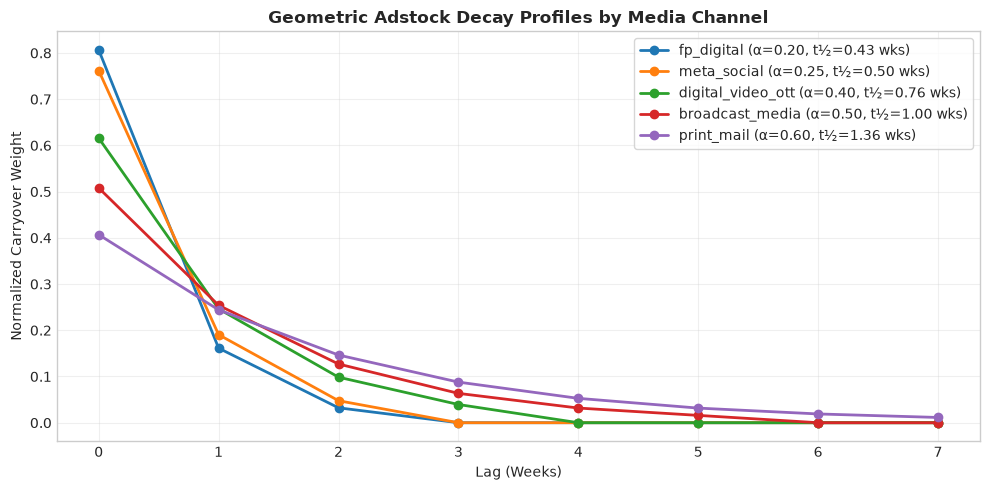

In [20]:
# Configuration dictionary matching Cell 7
fixed_media_config = {
    "fp_digital":        {"alpha": 0.20, "l_max": 3},
    "meta_social":       {"alpha": 0.25, "l_max": 3},
    "digital_video_ott": {"alpha": 0.40, "l_max": 4},
    "broadcast_media":   {"alpha": 0.50, "l_max": 6},
    "print_mail":        {"alpha": 0.60, "l_max": 8},
}

fig, ax = plt.subplots(figsize=(10, 5))
max_l = 8

for chan, cfg in fixed_media_config.items():
    alpha = cfg["alpha"]
    l_max = cfg["l_max"]
    
    # Calculate normalized weights over lag duration
    raw_weights = np.power(alpha, np.arange(l_max))
    normalized_weights = raw_weights / raw_weights.sum()
    
    # Pad with zeros for visual comparison up to max_l
    padded_weights = np.zeros(max_l)
    padded_weights[:l_max] = normalized_weights
    
    half_life = -np.log(2) / np.log(alpha)
    ax.plot(
        np.arange(max_l), 
        padded_weights, 
        marker='o', 
        linewidth=2, 
        label=f"{chan} (α={alpha:.2f}, t½={half_life:.2f} wks)"
    )

ax.set_title("Geometric Adstock Decay Profiles by Media Channel", fontsize=12, fontweight="bold")
ax.set_xlabel("Lag (Weeks)", fontsize=10)
ax.set_ylabel("Normalized Carryover Weight", fontsize=10)
ax.set_xticks(np.arange(max_l))
ax.grid(True, alpha=0.3)
ax.legend(loc="upper right", frameon=True)

plt.tight_layout()
plt.show()

In [30]:
import optuna
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import pytensor.tensor as pt
import logging
import warnings

# Suppress Optuna/PyMC verbose logs during tuning trials
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings('ignore')

# 1. Define Master Channels and Maximum Global Buffer
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

n_obs = len(df_model)
n_media = len(media_channels)
max_global_lag = 12  # Upper bound buffer for pre-computing lag matrices

sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Pre-normalize raw media spend
X_media_raw = np.zeros((n_obs, n_media))
for i, col in enumerate(media_channels):
    c_mean = df_model[col].mean()
    X_media_raw[:, i] = (df_model[col] / (c_mean if c_mean > 0 else 1.0)).values

# Pre-compute master 12-week lag tensor: Shape (n_obs, n_media, 12)
X_master_lags = np.zeros((n_obs, n_media, max_global_lag))
for l in range(max_global_lag):
    for m in range(n_media):
        X_master_lags[:, m, l] = np.pad(X_media_raw[:, m], (l, 0))[:n_obs]


# 2. Optuna Objective Function
def objective(trial):
    # Channel-specific bounded search ranges based on automotive retail physics
    param_ranges = {
        'fp_digital':        {'alpha': (0.05, 0.30), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.15, 0.35)},
        'meta_social':       {'alpha': (0.10, 0.35), 'lmax': (2, 5),  'k': (0.8, 2.5), 's': (0.8, 1.4), 'beta_mu': (0.10, 0.25)},
        'digital_video_ott': {'alpha': (0.20, 0.50), 'lmax': (3, 8),  'k': (0.8, 2.5), 's': (0.8, 1.5), 'beta_mu': (0.08, 0.20)},
        'broadcast_media':   {'alpha': (0.30, 0.65), 'lmax': (4, 10), 'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)},
        'print_mail':        {'alpha': (0.35, 0.70), 'lmax': (4, 12), 'k': (0.8, 2.5), 's': (0.8, 1.6), 'beta_mu': (0.05, 0.15)},
    }
    
    alpha_vals, k_vals, s_vals, beta_mus, lmax_vals = [], [], [], [], []
    
    for chan in media_channels:
        bounds = param_ranges[chan]
        alpha_vals.append(trial.suggest_float(f"alpha_{chan}", bounds['alpha'][0], bounds['alpha'][1]))
        lmax_vals.append(trial.suggest_int(f"lmax_{chan}", bounds['lmax'][0], bounds['lmax'][1]))
        k_vals.append(trial.suggest_float(f"k_{chan}", bounds['k'][0], bounds['k'][1]))
        s_vals.append(trial.suggest_float(f"s_{chan}", bounds['s'][0], bounds['s'][1]))
        beta_mus.append(trial.suggest_float(f"beta_mu_{chan}", bounds['beta_mu'][0], bounds['beta_mu'][1]))

    # Compute trial-specific adstock weights across active lag windows
    adstocked_media_list = []
    for m, chan in enumerate(media_channels):
        a_m = alpha_vals[m]
        l_m = lmax_vals[m]
        
        lags_m = np.arange(l_m)
        weights_m = np.power(a_m, lags_m)
        weights_m /= weights_m.sum()
        
        # Apply convolution for channel m over its suggested lmax window
        x_lag_m = X_master_lags[:, m, :l_m]
        adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
        adstocked_media_list.append(adstocked_m)
        
    X_adstocked_trial = np.column_stack(adstocked_media_list)

    # 3. Fast MCMC PyMC Model Trial
    try:
        with pm.Model(coords={"obs_id": df_model.index, "channel": media_channels, "fourier_term": fourier_cols}) as model:
            # Data Containers
            adstocked_data = pm.Data("adstocked_data", X_adstocked_trial, dims=("obs_id", "channel"))
            fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
            inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
            eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
            macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

            # Priors
            intercept = pm.Normal("intercept", mu=0.70, sigma=0.08)
            beta_channel = pm.TruncatedNormal("beta_channel", mu=np.array(beta_mus), sigma=0.05, lower=0.0, dims="channel")
            k_sat = pm.Gamma("k_sat", alpha=np.array(k_vals) * 10, beta=10, dims="channel")
            s_slope = pm.Gamma("s_slope", alpha=np.array(s_vals) * 10, beta=10, dims="channel")

            # Saturation Transformation
            media_sat = (adstocked_data ** s_slope) / (adstocked_data ** s_slope + k_sat ** s_slope + 1e-8)
            media_contrib = pt.sum(media_sat * beta_channel, axis=1)

            # Controls
            b_inv = pm.HalfNormal("beta_inv", sigma=0.10)
            b_eom = pm.HalfNormal("beta_eom", sigma=0.15)
            b_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
            b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

            mu = (
                intercept 
                + media_contrib 
                + (b_inv * inv_data) 
                + (b_eom * eom_data) 
                + (b_macro * macro_data) 
                + pm.math.dot(fourier_data, b_fourier)
            )

            pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled, dims="obs_id")

            # Fast MCMC sampling for HPO trial evaluation
            idata_trial = pm.sample(
                draws=400, 
                tune=400, 
                chains=2, 
                target_accept=0.95, 
                progressbar=False, 
                random_seed=42
            )
            pm.compute_log_likelihood(idata_trial)

            # Score Trial via Out-of-Sample ELPD LOO
            loo_res = az.loo(idata_trial)
            
            if hasattr(loo_res, "elpd_loo"):
                return float(loo_res.elpd_loo)
            else:
                return float(loo_res.elpd)

    except Exception as e:
        # Return penalizing score on MCMC failure
        return -9999.0


# 4. Execute Optuna Study
print("🚀 Starting Optuna Bayesian Prior Optimization Study (15 Trials)...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=15)

print("\n" + "=" * 80)
print("OPTIMAL PRIOR CONFIGURATION FOUND BY OPTUNA (MAX ELPD_LOO)")
print("=" * 80)
print(f"Best ELPD_LOO Score: {study.best_value:.4f}\n")

# Format Best Parameters as Production Dictionary
best_priors_config = {}
for chan in media_channels:
    best_priors_config[chan] = {
        'alpha': study.best_params[f"alpha_{chan}"],
        'lmax': study.best_params[f"lmax_{chan}"],
        'k_sat': study.best_params[f"k_{chan}"],
        's_slope': study.best_params[f"s_{chan}"],
        'beta_mu': study.best_params[f"beta_mu_{chan}"]
    }

best_priors_df = pd.DataFrame(best_priors_config).T
print(best_priors_df.round(4))

🚀 Starting Optuna Bayesian Prior Optimization Study (15 Trials)...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 5 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


...

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]
Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 4 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details



OPTIMAL PRIOR CONFIGURATION FOUND BY OPTUNA (MAX ELPD_LOO)
Best ELPD_LOO Score: -17.3942

                   alpha   lmax  k_sat  s_slope  beta_mu
fp_digital        0.2961 3.0000 2.4312   1.3800   0.1504
meta_social       0.3480 4.0000 1.6479   1.0479   0.1053
digital_video_ott 0.2093 3.0000 1.6738   1.4614   0.1980
broadcast_media   0.4616 7.0000 2.4856   1.1418   0.1390
print_mail        0.3784 6.0000 0.8426   1.1329   0.0954


# 8. Production PyMC Bayesian MMM Model Specification & Sampling

## Purpose
Specify and sample the refactored Bayesian MMM using PyMC v5+.

## Model Mathematical Equation
$$\tilde{y}_t = \alpha_0 + \sum_{m=1}^{5} \beta_m X^*_{t,m} + \beta_{\text{inv}} Z_{\text{inv},t} + \beta_{\text{eom}} \cdot \text{EOM}_t + \beta_{\text{macro}} Z_{\text{macro},t} + \sum_{j=1}^{4} \gamma_j F_{j,t} + \epsilon_t$$

## Informative Priors Strategy
* **Baseline Intercept ($\alpha_0$)**: $\text{Normal}(\mu=0.60, \sigma=0.10)$ (~60% baseline sales).
* **Media Coefficients ($\beta_m$)**: $\text{HalfNormal}(\sigma=0.20)$ (Enforces strict non-negativity).
* **End-of-Month Push ($\beta_{\text{eom}}$)**: $\text{Normal}(\mu=0.35, \sigma=0.08)$ (Informed prior capturing Month-End stair-step incentive spikes).
* **Inventory Constraint ($\beta_{\text{inv}}$)**: $\text{HalfNormal}(\sigma=0.15)$ (Positive stock availability effect).
* **Macro Headwind ($\beta_{\text{macro}}$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Fourier Seasonality ($\gamma_j$)**: $\text{Normal}(\mu=0.0, \sigma=0.10)$.
* **Observation Noise ($\epsilon_t$)**: $\text{StudentT}(\nu, \mu, \sigma)$ (Robust likelihood handling outlier vehicle spikes).

In [31]:
import numpy as np
import pandas as pd
import pymc as pm
import pytensor.tensor as pt

# ==============================================================================
# CELL 8: PRODUCTION MMM WITH OPTUNA-OPTIMIZED PRIORS
# ==============================================================================

# 1. Channels & Optuna Best Parameters
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
fourier_cols = ['sin_order1', 'cos_order1', 'sin_order2', 'cos_order2']

# Optuna Best Config
optuna_alpha   = np.array([0.2961, 0.3480, 0.2093, 0.4616, 0.3784])
optuna_lmax    = np.array([3, 4, 3, 7, 6], dtype=int)
optuna_ksat    = np.array([2.4312, 1.6479, 1.6738, 2.4856, 0.8426])
optuna_slope   = np.array([1.3800, 1.0479, 1.4614, 1.1418, 1.1329])
optuna_beta_mu = np.array([0.1504, 0.1053, 0.1980, 0.1390, 0.0954])

n_obs = len(df_model)
n_media = len(media_channels)
max_global_lag = 12

sales_mean = df_model['sales'].mean()
y_scaled = (df_model['sales'] / sales_mean).values

# Normalize spend by sample means
X_media_raw = np.zeros((n_obs, n_media))
for i, col in enumerate(media_channels):
    c_mean = df_model[col].mean()
    X_media_raw[:, i] = (df_model[col] / (c_mean if c_mean > 0 else 1.0)).values

# Compute Channel-Specific Adstocked Matrices using Optuna lmax & alpha
adstocked_media_list = []
for m, chan in enumerate(media_channels):
    a_m = optuna_alpha[m]
    l_m = optuna_lmax[m]
    
    lags_m = np.arange(l_m)
    weights_m = np.power(a_m, lags_m)
    weights_m /= weights_m.sum()
    
    # Pre-pad lag matrix
    x_lag_m = np.zeros((n_obs, l_m))
    for l in range(l_m):
        x_lag_m[:, l] = np.pad(X_media_raw[:, m], (l, 0))[:n_obs]
        
    adstocked_m = np.sum(x_lag_m * weights_m[None, :], axis=1)
    adstocked_media_list.append(adstocked_m)

X_adstocked_optuna = np.column_stack(adstocked_media_list)

# 2. PyMC Model Definition
with pm.Model(coords={
    "obs_id": df_model.index,
    "channel": media_channels,
    "fourier_term": fourier_cols
}) as mmm_model:

    # Data Containers
    adstocked_data = pm.Data("adstocked_data", X_adstocked_optuna, dims=("obs_id", "channel"))
    fourier_data = pm.Data("fourier_data", df_model[fourier_cols].values, dims=("obs_id", "fourier_term"))
    inv_data = pm.Data("inv_data", df_model["inventory_index"].values, dims="obs_id")
    eom_data = pm.Data("eom_data", df_model["eom_intensity"].values, dims="obs_id")
    macro_data = pm.Data("macro_data", df_model["macro_stress_index"].values, dims="obs_id")

    # Intercept & Effect Priors Centered on Optuna Results
    intercept = pm.Normal("intercept", mu=0.70, sigma=0.08)
    beta_channel = pm.TruncatedNormal("beta_channel", mu=optuna_beta_mu, sigma=0.05, lower=0.0, dims="channel")
    
    # Saturation Priors Centered on Optuna Results
    k_sat = pm.Gamma("k_sat", alpha=optuna_ksat * 10, beta=10, dims="channel")
    s_slope = pm.Gamma("s_slope", alpha=optuna_slope * 10, beta=10, dims="channel")

    # Hill Transformation
    media_sat = (adstocked_data ** s_slope) / (adstocked_data ** s_slope + k_sat ** s_slope + 1e-8)
    media_contrib = pt.sum(media_sat * beta_channel, axis=1)

    # Controls
    b_inv = pm.HalfNormal("beta_inv", sigma=0.10)
    b_eom = pm.HalfNormal("beta_eom", sigma=0.15)
    b_macro = pm.Normal("beta_macro", mu=0.0, sigma=0.08)
    b_fourier = pm.Normal("beta_fourier", mu=0.0, sigma=0.08, dims="fourier_term")

    mu = (
        intercept 
        + media_contrib 
        + (b_inv * inv_data) 
        + (b_eom * eom_data) 
        + (b_macro * macro_data) 
        + pm.math.dot(fourier_data, b_fourier)
    )

    pm.StudentT("likelihood", nu=7, mu=mu, sigma=pm.Exponential("sigma", lam=10.0), observed=y_scaled, dims="obs_id")

# 3. MCMC Sampling
with mmm_model:
    print("🚀 Sampling Production Model with Optuna-Optimized Priors...")
    idata = pm.sample(draws=1000, tune=1000, chains=4, target_accept=0.98, random_seed=42)
    pm.compute_log_likelihood(idata)
    pm.sample_posterior_predictive(idata, extend_inferencedata=True)

print("✅ Sampling complete. Proceed to Cell 9 & Cell 10 for diagnostics.")

🚀 Sampling Production Model with Optuna-Optimized Priors...


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 2 jobs)
NUTS: [intercept, beta_channel, k_sat, s_slope, beta_inv, beta_eom, beta_macro, beta_fourier, sigma]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 20 seconds.


Sampling: [likelihood]


✅ Sampling complete. Proceed to Cell 9 & Cell 10 for diagnostics.


# 9. MCMC Convergence Diagnostics & Predictive Accuracy

## Purpose
Evaluate MCMC sampling health and quantify out-of-sample predictive accuracy in actual vehicle units.

## Diagnostic Benchmarks (Gelman et al., 2013)
1. **Divergent Transitions**: Must be 0.
2. **Gelman-Rubin ($\hat{R}$)**: Must be $\le 1.01$ across all parameters to confirm chain mixing.
3. **Bulk Effective Sample Size (ESS)**: Must be $> 400$ for reliable posterior summaries.
4. **Pareto $k$ Diagnostic (LOO-CV)**: Must be $< 0.7$ for all observations to ensure no individual week acts as an influential outlier.

## Model Accuracy Metrics
* **$R^2$ (Coefficient of Determination)**: $1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}$
* **MAPE (%)**: Mean Absolute Percentage Error on unscaled weekly vehicle sales.
* **RMSE**: Root Mean Squared Error in vehicle units.

1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK
Total Divergent Transitions: 0
✅ No divergences detected. Sampler geometry is healthy.
Max R-hat (Target <= 1.01): 1.003
Min Bulk ESS (Target > 400): 2978.4
🚀 ALL CONVERGENCE CHECKS PASSED!


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
intercept,0.758,0.039,0.69,0.82,4159,3184,1.00,0.00061,0.00054
beta_channel[fp_digital],0.151,0.05,0.068,0.23,3708,1693,1.00,0.00082,0.0011
beta_channel[meta_social],0.105,0.047,0.032,0.18,3665,1971,1.00,0.00072,0.00065
beta_channel[digital_video_ott],0.19,0.045,0.12,0.26,5359,2653,1.00,0.00061,0.00075
beta_channel[broadcast_media],0.139,0.047,0.063,0.22,3832,1710,1.00,0.00075,0.00093
beta_channel[print_mail],0.123,0.043,0.055,0.19,4250,2284,1.00,0.00064,0.00066
beta_inv,0.0182,0.0156,0.0011,0.048,3497,2079,1.00,0.00022,0.00026
beta_eom,0.133,0.063,0.033,0.24,2978,1743,1.00,0.0011,0.00093
beta_macro,-0.0496,0.0213,-0.084,-0.015,4122,3067,1.00,0.00033,0.00033
sigma,0.2409,0.0204,0.21,0.28,6308,2950,1.00,0.00026,0.00037



2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
Model R-Squared (R²):                     0.1731
Mean Absolute Percentage Error (MAPE):    23.88%
Root Mean Squared Error (RMSE):           3.70 vehicles / week

3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
ELPD LOO: -17.71 (SE: 7.32)
Max Pareto k (Target < 0.7): 0.41
✅ Pareto k values are healthy. Out-of-sample prediction is reliable.


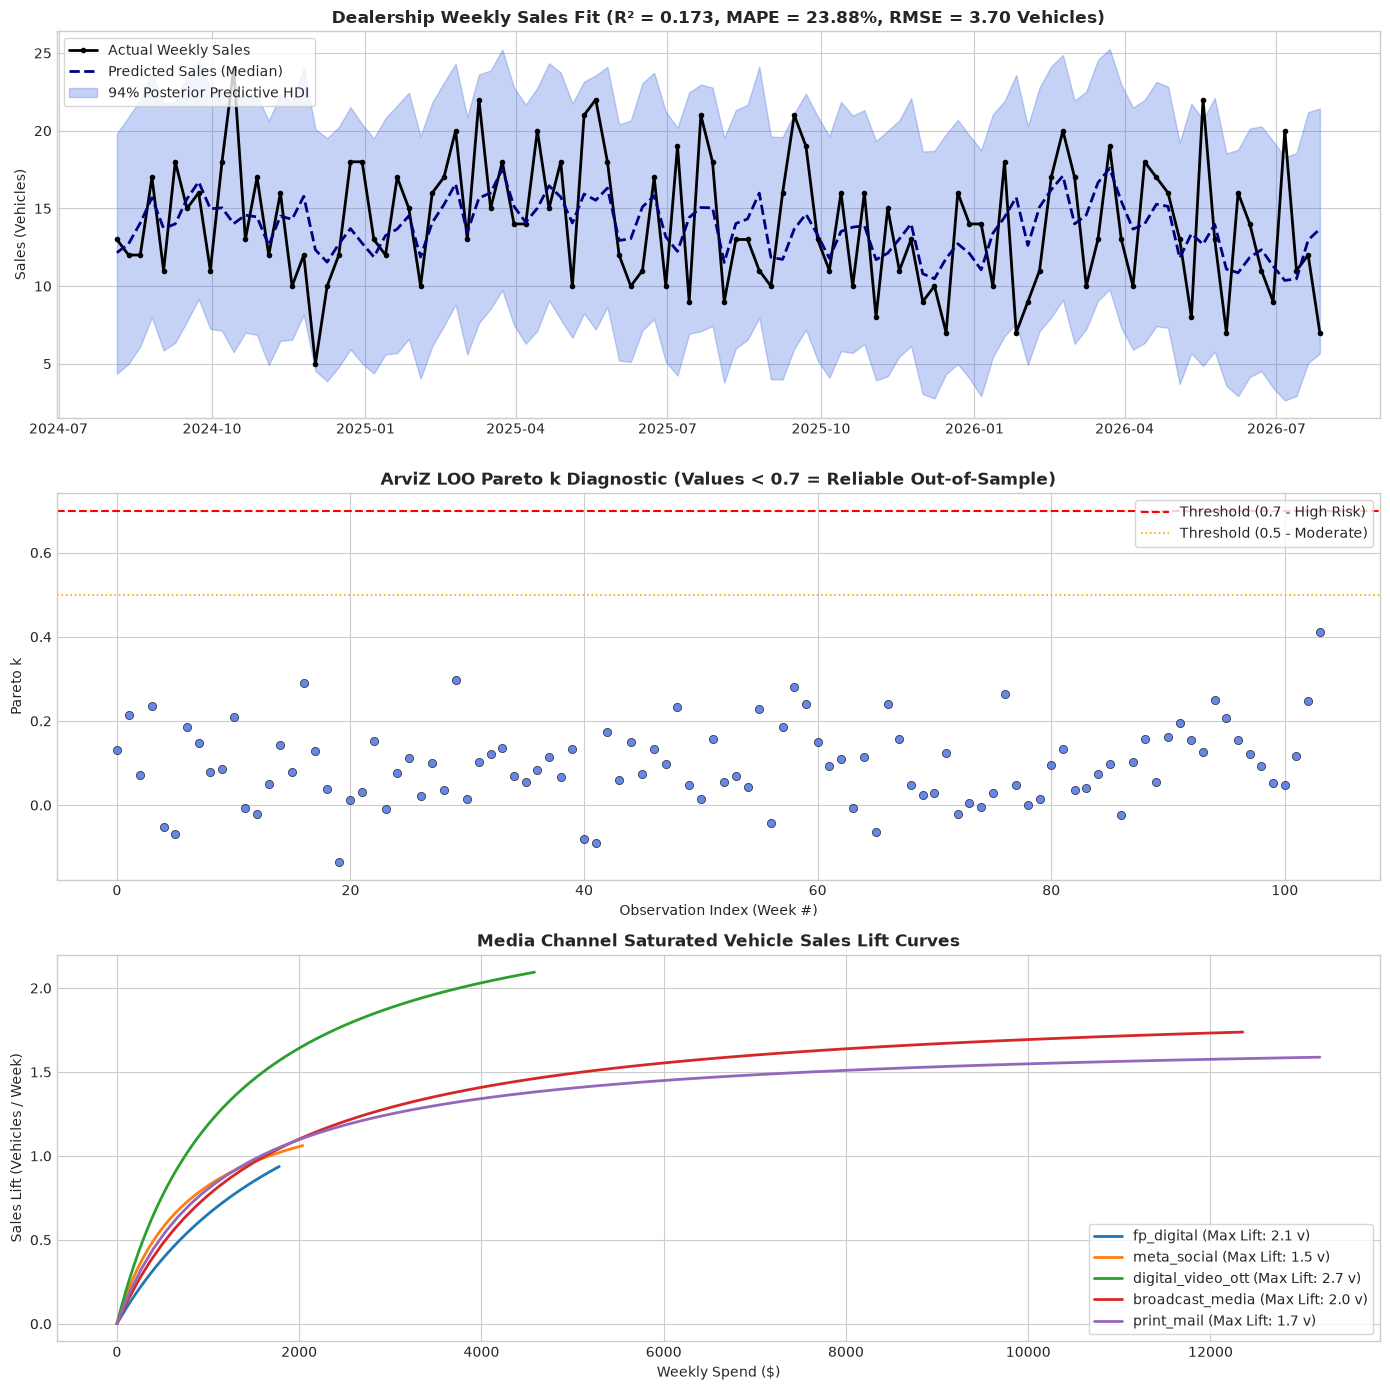

In [32]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

# ==============================================================================
# CELL 10: DIAGNOSTICS & 3-PANEL DASHBOARD
# ==============================================================================

media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sales_mean = df_model['sales'].mean()

print("=" * 80)
print("1. MCMC CONVERGENCE & DIAGNOSTIC HEALTH CHECK")
print("=" * 80)

# Check Divergences
divergences = idata.sample_stats["divergences"].values.sum()
print(f"Total Divergent Transitions: {divergences}")
if divergences > 0:
    print("⚠️ WARNING: Divergences detected. Consider increasing target_accept.")
else:
    print("✅ No divergences detected. Sampler geometry is healthy.")

# Summary Table
summary_stats = az.summary(
    idata, 
    var_names=["intercept", "beta_channel", "beta_inv", "beta_eom", "beta_macro", "sigma"]
)

max_rhat = summary_stats["r_hat"].max()
min_ess = summary_stats["ess_bulk"].min()

print(f"Max R-hat (Target <= 1.01): {max_rhat:.3f}")
print(f"Min Bulk ESS (Target > 400): {min_ess:.1f}")

if max_rhat <= 1.01 and min_ess >= 400 and divergences == 0:
    print("🚀 ALL CONVERGENCE CHECKS PASSED!")

display(summary_stats)

# ==============================================================================
# 2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)
# ==============================================================================
print("\n" + "=" * 80)
print("2. MODEL FIT & ACCURACY METRICS (UNSCALED VEHICLE UNITS)")
print("=" * 80)

ppc_extracted = az.extract(idata, group="posterior_predictive")

if isinstance(ppc_extracted, xr.Dataset):
    if "likelihood" in ppc_extracted:
        ppc_data = ppc_extracted["likelihood"].values
    else:
        first_var = list(ppc_extracted.data_vars)[0]
        ppc_data = ppc_extracted[first_var].values
elif isinstance(ppc_extracted, xr.DataArray):
    ppc_data = ppc_extracted.values
else:
    ppc_data = np.asarray(ppc_extracted)

if ppc_data.shape[0] == len(df_model):
    ppc_samples = ppc_data.T * sales_mean
else:
    ppc_samples = ppc_data * sales_mean

actual_sales = df_model['sales'].values
pred_median = np.median(ppc_samples, axis=0)
pred_lower = np.percentile(ppc_samples, 3, axis=0)   # 94% HDI Lower
pred_upper = np.percentile(ppc_samples, 97, axis=0)  # 94% HDI Upper

mape = np.mean(np.abs((actual_sales - pred_median) / actual_sales)) * 100
rmse = np.sqrt(np.mean((actual_sales - pred_median) ** 2))

ss_res = np.sum((actual_sales - pred_median) ** 2)
ss_tot = np.sum((actual_sales - actual_sales.mean()) ** 2)
r2 = float(1.0 - (ss_res / ss_tot))

print(f"Model R-Squared (R²):                     {r2:.4f}")
print(f"Mean Absolute Percentage Error (MAPE):    {mape:.2f}%")
print(f"Root Mean Squared Error (RMSE):           {rmse:.2f} vehicles / week")

# ==============================================================================
# 3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)
# ==============================================================================
print("\n" + "=" * 80)
print("3. LEAVE-ONE-OUT CROSS-VALIDATION (LOO-CV)")
print("=" * 80)

loo_res = az.loo(idata)

if hasattr(loo_res, "elpd_loo"):
    elpd_val = float(loo_res.elpd_loo)
elif hasattr(loo_res, "elpd"):
    elpd_val = float(loo_res.elpd)
elif "elpd_loo" in loo_res:
    elpd_val = float(loo_res["elpd_loo"])
else:
    elpd_val = float(loo_res["elpd"])

if hasattr(loo_res, "se"):
    se_val = float(loo_res.se)
elif hasattr(loo_res, "se_elpd_loo"):
    se_val = float(loo_res.se_elpd_loo)
else:
    se_val = float(loo_res["se"])

if hasattr(loo_res, "pareto_k"):
    pareto_k_obj = loo_res.pareto_k
elif hasattr(loo_res, "khat"):
    pareto_k_obj = loo_res.khat
else:
    pareto_k_obj = loo_res["pareto_k"]

if hasattr(pareto_k_obj, "values"):
    k_array = pareto_k_obj.values
else:
    k_array = np.asarray(pareto_k_obj)

max_k = float(np.max(k_array))

print(f"ELPD LOO: {elpd_val:.2f} (SE: {se_val:.2f})")
print(f"Max Pareto k (Target < 0.7): {max_k:.2f}")

if max_k < 0.7:
    print("✅ Pareto k values are healthy. Out-of-sample prediction is reliable.")
else:
    print("⚠️ High Pareto k detected. Inspect observations with k > 0.7.")

# ==============================================================================
# 4. 3-PANEL DIAGNOSTIC DASHBOARD
# ==============================================================================
fig, axes = plt.subplots(3, 1, figsize=(14, 14))
dates = pd.to_datetime(df_model['week_start'])

# Panel 1: Actual vs Predicted Sales Time Series
axes[0].plot(dates, actual_sales, color='black', linewidth=2, label='Actual Weekly Sales', marker='o', markersize=3)
axes[0].plot(dates, pred_median, color='navy', linestyle='--', linewidth=2, label='Predicted Sales (Median)')
axes[0].fill_between(dates, pred_lower, pred_upper, color='royalblue', alpha=0.3, label='94% Posterior Predictive HDI')
axes[0].set_title(f"Dealership Weekly Sales Fit (R² = {r2:.3f}, MAPE = {mape:.2f}%, RMSE = {rmse:.2f} Vehicles)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sales (Vehicles)", fontsize=10)
axes[0].legend(loc='upper left', frameon=True)

# Panel 2: Pareto k Scatter Diagnostic
axes[1].scatter(np.arange(len(k_array)), k_array, alpha=0.8, color='royalblue', edgecolor='black', linewidth=0.5, s=35)
axes[1].axhline(0.7, color='red', linestyle='--', linewidth=1.5, label='Threshold (0.7 - High Risk)')
axes[1].axhline(0.5, color='orange', linestyle=':', linewidth=1.2, label='Threshold (0.5 - Moderate)')
axes[1].set_title("ArviZ LOO Pareto k Diagnostic (Values < 0.7 = Reliable Out-of-Sample)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Pareto k", fontsize=10)
axes[1].set_xlabel("Observation Index (Week #)", fontsize=10)
axes[1].legend(loc='upper right', frameon=True)

# Panel 3: Pre-Transformed Saturated Lift Curves
post_means = idata.posterior.mean(dim=["chain", "draw"])
beta_means_veh = post_means["beta_channel"].values * sales_mean

if "k_sat" in post_means:
    k_sat_vals = post_means["k_sat"].values
elif "k_val" in post_means:
    k_sat_vals = post_means["k_val"].values
else:
    k_sat_vals = np.ones(len(media_channels))

for i, chan in enumerate(media_channels):
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_grid = np.linspace(0, max_spend, 100)
    c_mean = df_model[chan].mean() if df_model[chan].mean() > 0 else 1.0
    
    x_adstocked = x_grid / c_mean
    k_sat = float(k_sat_vals[i])
    
    y_lift = (x_adstocked / (x_adstocked + k_sat + 1e-8)) * beta_means_veh[i]
    axes[2].plot(x_grid, y_lift, label=f"{chan} (Max Lift: {beta_means_veh[i]:.1f} v)", linewidth=2)

axes[2].set_title("Media Channel Saturated Vehicle Sales Lift Curves", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE
          Channel Avg Spend ($/Wk) Max Lift (Vehicles) Lift at Avg Spend Cost Per Vehicle ($) Vehicles / $1k Spend
digital_video_ott          $723.57                2.66              0.98              $738.77                 1.35
      meta_social          $479.22                1.47              0.56              $862.55                 1.16
  broadcast_media          $621.36                1.96              0.56            $1,112.86                 0.90
       print_mail        $1,394.69                1.73              0.95            $1,471.85                 0.68
       fp_digital          $921.32                2.11              0.62            $1,494.18                 0.67


ValueError: Keyword arguments ['hdi_prob', 'ax'] have been passed as **kwargs but have no active aesthetic mapped to them. Keyword arguments must define values to use in their respective aesthetic mapping.

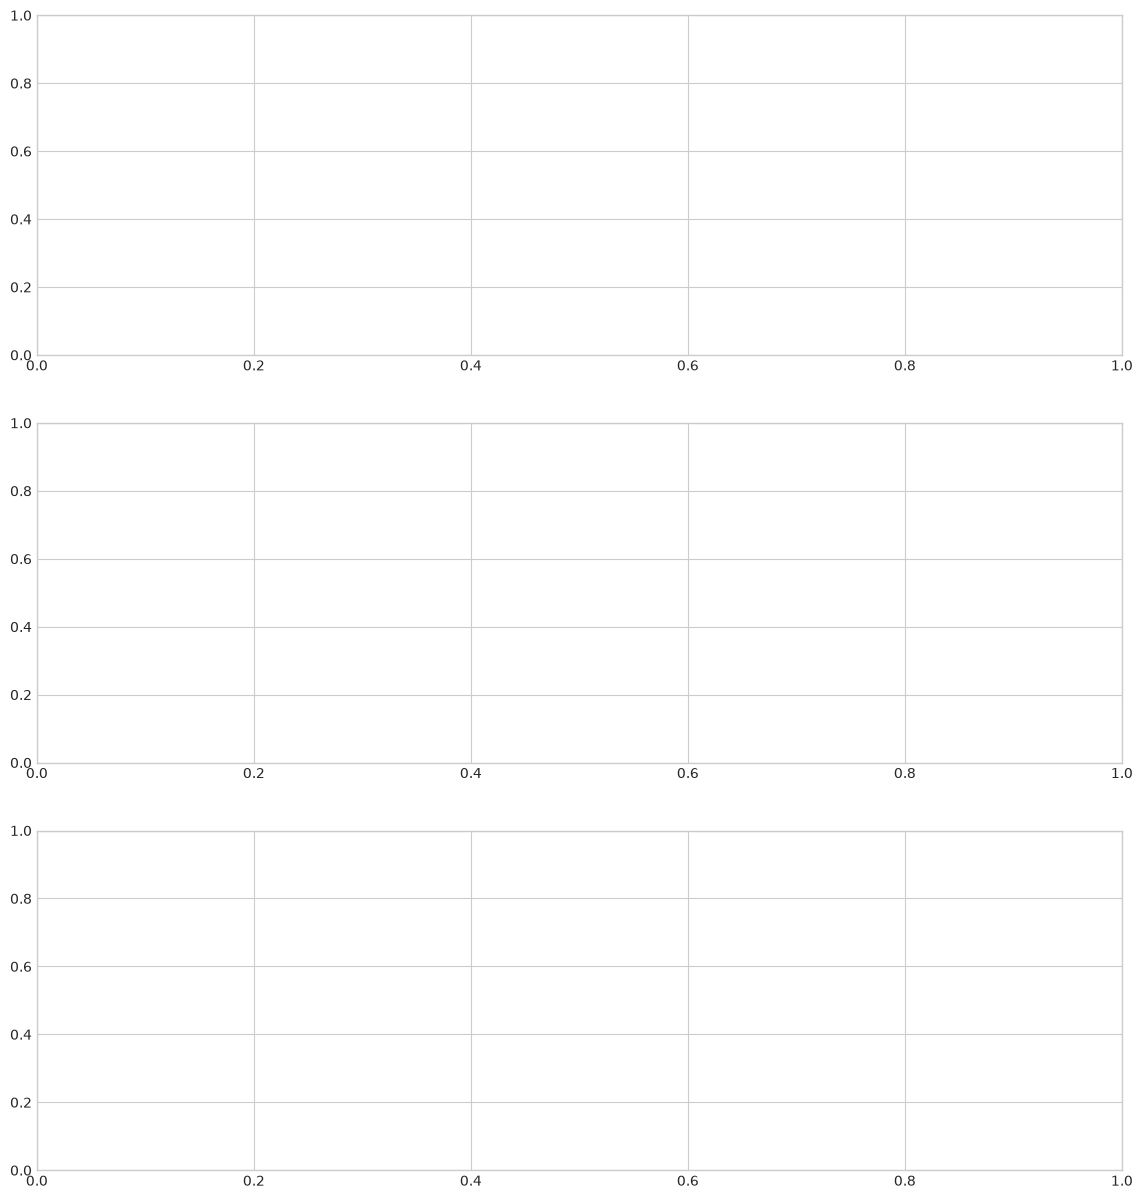

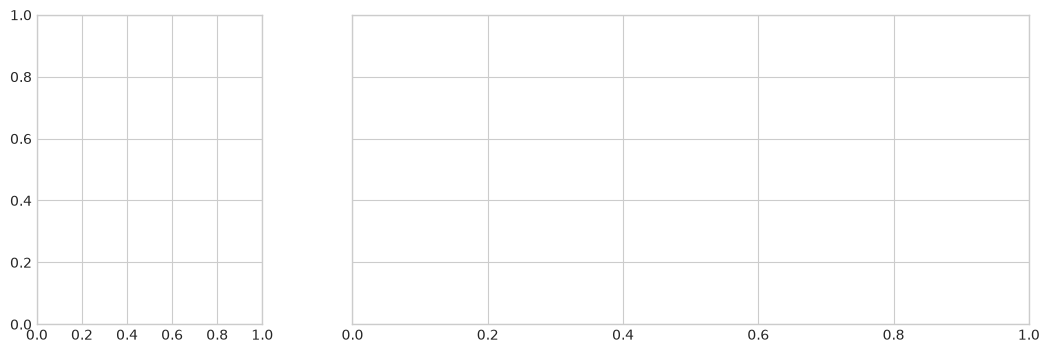

In [33]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ==============================================================================
# CELL 10: POST-RUN ANALYSIS, CPA TABLE, AND SATURATION DASHBOARD
# ==============================================================================

# 1. Global Scope Channel Definition (Fixes NameError)
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']

# 2. Extract Posterior Means & Sales Mean
sales_mean = df_model['sales'].mean()
post_means = idata.posterior.mean(dim=["chain", "draw"])
beta_means_veh = post_means["beta_channel"].values * sales_mean

# 3. Calculate Cost Per Vehicle Acquired (CPA) & Acquisition Efficiency
efficiency_records = []
for i, chan in enumerate(media_channels):
    avg_spend = df_model[chan].mean()
    if avg_spend == 0:
        avg_spend = 1.0
    
    # Handle coordinate naming across PyMC versions
    k_val = float(post_means["k_sat"].values[i]) if "k_sat" in post_means else float(post_means["k_val"].values[i])
    max_lift_veh = float(beta_means_veh[i])
    
    # Evaluate Reach curve at average weekly spend (scaled x = 1.0)
    x_scaled = 1.0
    lift_at_avg = (x_scaled / (x_scaled + k_val + 1e-8)) * max_lift_veh
    
    cost_per_vehicle = avg_spend / (lift_at_avg + 1e-9)
    vehicles_per_1k = (lift_at_avg / avg_spend) * 1000.0 if avg_spend > 0 else 0.0
    
    efficiency_records.append({
        "Channel": chan,
        "Avg Spend ($/Wk)": avg_spend,
        "Max Lift (Vehicles)": max_lift_veh,
        "Lift at Avg Spend": lift_at_avg,
        "Cost Per Vehicle ($)": cost_per_vehicle,
        "Vehicles / $1k Spend": vehicles_per_1k
    })

efficiency_df = pd.DataFrame(efficiency_records).sort_values("Cost Per Vehicle ($)")

print("=" * 80)
print("CHANNEL COST-EFFICIENCY & VEHICLE ACQUISITION TABLE")
print("=" * 80)
print(efficiency_df.to_string(index=False, formatters={
    "Avg Spend ($/Wk)": "${:,.2f}".format,
    "Max Lift (Vehicles)": "{:.2f}".format,
    "Lift at Avg Spend": "{:.2f}".format,
    "Cost Per Vehicle ($)": "${:,.2f}".format,
    "Vehicles / $1k Spend": "{:.2f}".format
}))

# 4. Three-Panel Dashboard
fig, axes = plt.subplots(3, 1, figsize=(14, 15))

# Panel 1: Posterior Beta Uncertainty (Forest Plot)
az.plot_forest(
    idata,
    var_names=["beta_channel"],
    combined=True,
    hdi_prob=0.89,
    ax=axes[0]
)
axes[0].set_title("89% Posterior HDI for Channel Betas (Scaled Lift)", fontsize=12, fontweight='bold')
axes[0].set_yticklabels(reversed(media_channels))

# Panel 2: Cost Per Vehicle Acquired (Bar Chart)
bars = axes[1].barh(efficiency_df["Channel"], efficiency_df["Cost Per Vehicle ($)"], color='skyblue', edgecolor='black')
axes[1].set_title("Cost Per Vehicle Acquired ($ / Vehicle)", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Cost ($)", fontsize=10)
axes[1].invert_yaxis()

for bar in bars:
    width = bar.get_width()
    axes[1].text(width + 30, bar.get_y() + bar.get_height()/2, f"${width:,.0f}", ha='left', va='center', fontsize=9)

# Panel 3: Pre-Transformed Saturated Lift Curves
for i, chan in enumerate(media_channels):
    max_spend = df_model[chan].max() * 1.2
    if max_spend == 0:
        max_spend = 1000.0
    x_spend_grid = np.linspace(0, max_spend, 100)
    
    c_mean = df_model[chan].mean()
    if c_mean == 0:
        c_mean = 1.0
    
    scaled_x = x_spend_grid / c_mean
    k_val = float(post_means["k_sat"].values[i]) if "k_sat" in post_means else float(post_means["k_val"].values[i])
    beta_veh = float(beta_means_veh[i])
    
    y_lift = (scaled_x / (scaled_x + k_val + 1e-8)) * beta_veh
    axes[2].plot(x_spend_grid, y_lift, label=f"{chan} (Max Lift: {beta_veh:.1f} veh)", linewidth=2.5)

axes[2].set_title("Media Channel Saturation Curves (Vehicle Sales Lift vs. Weekly Spend)", fontsize=12, fontweight='bold')
axes[2].set_ylabel("Sales Lift (Vehicles / Week)", fontsize=10)
axes[2].set_xlabel("Weekly Spend ($)", fontsize=10)
axes[2].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.show()

In [36]:
import numpy as np
import pandas as pd
import arviz as az
from scipy.optimize import minimize

# ==============================================================================
# BAYESIAN POSTERIOR UNCERTAINTY PROPAGATION IN BUDGET OPTIMIZATION
# ==============================================================================

# 1. Setup Parameters & Dimensions
media_channels = ['fp_digital', 'meta_social', 'digital_video_ott', 'broadcast_media', 'print_mail']
sales_mean = df_model['sales'].mean()

current_spends = np.array([df_model[c].mean() for c in media_channels])
total_budget = np.sum(current_spends)
c_means = np.array([df_model[c].mean() if df_model[c].mean() > 0 else 1.0 for c in media_channels])

# Flatten posterior chains into continuous draw dimension
post_draws = az.extract(idata, combined=True)
n_total_draws = post_draws.sizes['sample']

# Subsample D=200 random draws for Monte Carlo optimization
np.random.seed(42)
n_mc_samples = 200
draw_indices = np.random.choice(n_total_draws, size=n_mc_samples, replace=False)

# 2. Extract Posterior Tensors
beta_draws = post_draws["beta_channel"].values[:, draw_indices] * sales_mean  # Shape: (channel, D)
k_sat_draws = post_draws["k_sat"].values[:, draw_indices] if "k_sat" in post_draws else post_draws["k_val"].values[:, draw_indices]
s_slope_draws = post_draws["s_slope"].values[:, draw_indices] if "s_slope" in post_draws else np.ones((len(media_channels), n_mc_samples))

# 3. Monte Carlo Optimization Loop
optimal_spends_mc = np.zeros((n_mc_samples, len(media_channels)))
current_lifts_mc = np.zeros(n_mc_samples)
optimal_lifts_mc = np.zeros(n_mc_samples)

constraints = ({'type': 'eq', 'fun': lambda s: np.sum(s) - total_budget})
bounds = [(0.0, total_budget * 0.50) for _ in media_channels]

print(f"🚀 Running Monte Carlo Budget Optimization across {n_mc_samples} posterior draws...")

for d in range(n_mc_samples):
    b_d = beta_draws[:, d]
    k_d = k_sat_draws[:, d]
    s_d = s_slope_draws[:, d]

    def lift_func(spends):
        x_scaled = spends / c_means
        x_s = np.power(x_scaled, s_d)
        k_s = np.power(k_d, s_d)
        return np.sum((x_s / (x_s + k_s + 1e-8)) * b_d)

    # Current lift for draw d
    current_lifts_mc[d] = lift_func(current_spends)

    # Optimize spend for draw d
    res = minimize(
        lambda s: -lift_func(s),
        current_spends,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'eps': 1.0, 'ftol': 1e-8}
    )
    
    optimal_spends_mc[d, :] = res.x
    optimal_lifts_mc[d] = -res.fun

# 4. Compute Posterior Summaries (Mean & 89% HDI)
def get_hdi(arr):
    hdi = az.hdi(arr, hdi_prob=0.89)
    return hdi[0], hdi[1]

summary_rows = []
for i, chan in enumerate(media_channels):
    c_spend = current_spends[i]
    opt_spend_mean = np.mean(optimal_spends_mc[:, i])
    opt_spend_l89, opt_spend_u89 = get_hdi(optimal_spends_mc[:, i])
    
    summary_rows.append({
        "Channel": chan,
        "Current Spend ($)": f"${c_spend:,.2f}",
        "Optimal Spend Mean ($)": f"${opt_spend_mean:,.2f}",
        "89% HDI Optimal ($)": f"[${opt_spend_l89:,.0f} - ${opt_spend_u89:,.0f}]",
        "Net Shift ($)": f"${opt_spend_mean - c_spend:+,.2f}"
    })

executive_df = pd.DataFrame(summary_rows)

inc_lift_mc = optimal_lifts_mc - current_lifts_mc
inc_annual_mc = inc_lift_mc * 52

print("\n" + "=" * 90)
print("EXECUTIVE BUDGET REALLOCATION SUMMARY (POSTERIOR UNCERTAINTY PROPAGATED)")
print("=" * 90)
print(executive_df.to_string(index=False))

print("\n" + "-" * 90)
print(f"Current Weekly Vehicle Lift   : {np.mean(current_lifts_mc):.2f} v/wk (89% HDI: [{get_hdi(current_lifts_mc)[0]:.2f} - {get_hdi(current_lifts_mc)[1]:.2f}])")
print(f"Optimized Weekly Vehicle Lift : {np.mean(optimal_lifts_mc):.2f} v/wk (89% HDI: [{get_hdi(optimal_lifts_mc)[0]:.2f} - {get_hdi(optimal_lifts_mc)[1]:.2f}])")
print(f"Projected Incremental Gain    : +{np.mean(inc_lift_mc):.2f} v/wk (89% HDI: [+{get_hdi(inc_lift_mc)[0]:.2f} - +{get_hdi(inc_lift_mc)[1]:.2f}])")
print(f"Projected Annual Vehicle Gain : +{np.mean(inc_annual_mc):.1f} v/year (89% HDI: [+{get_hdi(inc_annual_mc)[0]:.1f} - +{get_hdi(inc_annual_mc)[1]:.1f}])")
print("-" * 90)

🚀 Running Monte Carlo Budget Optimization across 200 posterior draws...


TypeError: hdi got an unexpected keyword argument: 'hdi_prob'. The 'hdi_prob' argument was renamed to 'prob' in arviz-stats 1.0. Use 'prob' instead (e.g. prob=0.95). See the HDI Function Changes section in the migration guide: https://python.arviz.org/en/stable/user_guide/migration_guide.html#hdi-function-changes